## Simulation 1: Monte Carlo Safety Stock Validation
##### Validates the theoretical service levels from the IndiGo pilot inventory model by simulating monthly pilot demand and measuring empirical stockout frequency across 5 candidate service levels.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

### Model Parameters

In [2]:
BASE_DEMAND   = 2085    # Base pilot requirement (post-FDTL)
SIGMA_TOTAL   = 197     # Combined demand std dev (absence + ops + seasonal)
C_H           = 52.05   # Holding cost (₹ lakh/pilot/year)
C_S           = 15      # Stockout cost (₹ lakh/cancellation)
H_POST_FDTL   = 90      # Productive hours/pilot/month post-FDTL
PILOTS_FLIGHT = 2       # Cockpit crew per flight
AVG_DURATION  = 2       # Average domestic flight duration (hours)

In [3]:
# Service level configurations from the case study
SL_CONFIG = {
    0.90: {"z": 1.28, "ss": 252, "N": 2337},
    0.95: {"z": 1.65, "ss": 325, "N": 2410},
    0.97: {"z": 1.88, "ss": 370, "N": 2455},
    0.99: {"z": 2.33, "ss": 459, "N": 2544},
    0.995:{"z": 2.58, "ss": 508, "N": 2593}}

In [5]:
N_TRIALS = 10_000   # Number of simulated months
SEED = 42

### Simulation

Simulate n_trials months of pilot demand and compute:

    - Empirical service level (fraction of months with no stockout)

    - Average shortfall per month
    
    - Distribution of demand

In [ ]:
def run_monte_carlo(N_pilots, n_trials=N_TRIALS, seed=SEED):
    rng = np.random.default_rng(seed)
    demand = rng.normal(loc=BASE_DEMAND, scale=SIGMA_TOTAL, size=n_trials)
    demand = np.round(demand).astype(int)
 
    stockout_mask  = demand > N_pilots
    n_stockouts    = stockout_mask.sum()
    empirical_sl   = 1 - n_stockouts / n_trials
    shortfalls     = np.where(stockout_mask, demand - N_pilots, 0)
    avg_shortfall  = shortfalls.mean()
 
    return {
        "demand":       demand,
        "empirical_sl": empirical_sl,
        "n_stockouts":  n_stockouts,
        "avg_shortfall":avg_shortfall,
    }

Unit normal loss function L(z) = φ(z) - z[1 - Φ(z)]

In [7]:
def theoretical_loss(z):
    return norm.pdf(z) - z * (1 - norm.cdf(z))

### Main

In [9]:
def main():
    print("  Monte Carlo Safety Stock Validation - IndiGo Pilot Model")
    print(f"  Trials per service level : {N_TRIALS:,}")
    print(f"  Base demand (μ)          : {BASE_DEMAND:,} pilots")
    print(f"  Std deviation (σ)        : {SIGMA_TOTAL} pilots")
    print()

    results = {}
    for sl, cfg in SL_CONFIG.items():
        res = run_monte_carlo(cfg["N"])
        results[sl] = {**cfg, **res}
        diff = (res["empirical_sl"] - sl) * 100
        print(
            f"  SL {sl*100:4.1f}%  |  N={cfg['N']:,}  |  "
            f"Theoretical: {sl*100:.1f}%  |  "
            f"Simulated: {res['empirical_sl']*100:.2f}%  |  "
            f"Δ = {diff:+.2f}pp  |  "
            f"Stockouts: {res['n_stockouts']:,}"
        )
 
    print()
    print("  Optimal (99%): cost-minimising service level from case study")
    print("=" * 65)
 
    # ── Figures ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        "Monte Carlo Validation — IndiGo Pilot Safety Stock Model",
        fontsize=13, fontweight="bold", y=1.01
    )
 
    # Figure 1: Demand histogram for optimal (99%) service level
    ax = axes[0]
    opt_sl  = 0.99
    opt_cfg = results[opt_sl]
    N_opt   = opt_cfg["N"]
    demand  = opt_cfg["demand"]
 
    bins = np.linspace(demand.min(), demand.max(), 45)
    colors = ["#e34948" if b + (bins[1]-bins[0]) > N_opt else "#2a78d6"
              for b in bins[:-1]]
 
    ax.hist(demand, bins=bins, color="#2a78d6", edgecolor="white",
            linewidth=0.3, zorder=2)
 
    # Recolour stockout bins
    n_vals, bin_edges = np.histogram(demand, bins=bins)
    for i, (left, right) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        if left > N_opt:
            ax.bar(left, n_vals[i], width=(right - left),
                   color="#e34948", edgecolor="white",
                   linewidth=0.3, align="edge", zorder=3)
 
    ax.axvline(N_opt, color="#1baf7a", linewidth=2,
               linestyle="--", label=f"N* = {N_opt:,} (optimal headcount)", zorder=4)
 
    ax.set_xlabel("Monthly pilot demand (pilots)", fontsize=11)
    ax.set_ylabel("Number of simulated months", fontsize=11)
    ax.set_title(
        f"Demand distribution at 99% service level\n"
        f"({N_TRIALS:,} trials · empirical SL = "
        f"{opt_cfg['empirical_sl']*100:.2f}%)",
        fontsize=11
    )
    blue_patch  = mpatches.Patch(color="#2a78d6", label="In-stock months")
    red_patch   = mpatches.Patch(color="#e34948", label=f"Stockout months ({opt_cfg['n_stockouts']:,})")
    green_line  = plt.Line2D([0],[0], color="#1baf7a", linewidth=2,
                             linestyle="--", label=f"N* = {N_opt:,}")
    ax.legend(handles=[blue_patch, red_patch, green_line], fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3, zorder=0)
 
    # Figure 2: Theoretical vs simulated SL comparison
    ax2 = axes[1]
    sl_labels   = [f"{sl*100:.1f}%" for sl in SL_CONFIG]
    theory_vals = [sl * 100 for sl in SL_CONFIG]
    sim_vals    = [results[sl]["empirical_sl"] * 100 for sl in SL_CONFIG]
 
    x = np.arange(len(sl_labels))
    w = 0.35
    bars1 = ax2.bar(x - w/2, theory_vals, w, label="Theoretical SL",
                    color="#2a78d6", alpha=0.85, zorder=2)
    bars2 = ax2.bar(x + w/2, sim_vals, w, label="Simulated SL",
                    color="#1baf7a", alpha=0.85, zorder=2)
 
    # Annotate delta
    for i, (t, s) in enumerate(zip(theory_vals, sim_vals)):
        delta = s - t
        ax2.text(x[i] + w/2, s + 0.02, f"{delta:+.2f}pp",
                 ha="center", va="bottom", fontsize=8, color="#555")
 
    ax2.set_ylim(88, 100.5)
    ax2.set_xticks(x)
    ax2.set_xticklabels(sl_labels)
    ax2.set_xlabel("Target service level", fontsize=11)
    ax2.set_ylabel("Service level (%)", fontsize=11)
    ax2.set_title(
        "Theoretical vs simulated service levels\n"
        "(convergence validates model assumptions)",
        fontsize=11
    )
    ax2.legend(fontsize=9)
    ax2.spines[["top","right"]].set_visible(False)
    ax2.grid(axis="y", alpha=0.3, zorder=0)
 
    plt.tight_layout()
    plt.savefig("simulation_1_monte_carlo.png", dpi=150, bbox_inches="tight")
    print("\n  Figure saved → simulation_1_monte_carlo.png")
    plt.show()

  Monte Carlo Safety Stock Validation - IndiGo Pilot Model
  Trials per service level : 10,000
  Base demand (μ)          : 2,085 pilots
  Std deviation (σ)        : 197 pilots

  SL 90.0%  |  N=2,337  |  Theoretical: 90.0%  |  Simulated: 90.05%  |  Δ = +0.05pp  |  Stockouts: 995
  SL 95.0%  |  N=2,410  |  Theoretical: 95.0%  |  Simulated: 95.12%  |  Δ = +0.12pp  |  Stockouts: 488
  SL 97.0%  |  N=2,455  |  Theoretical: 97.0%  |  Simulated: 96.95%  |  Δ = -0.05pp  |  Stockouts: 305
  SL 99.0%  |  N=2,544  |  Theoretical: 99.0%  |  Simulated: 98.94%  |  Δ = -0.06pp  |  Stockouts: 106
  SL 99.5%  |  N=2,593  |  Theoretical: 99.5%  |  Simulated: 99.48%  |  Δ = -0.02pp  |  Stockouts: 52

  Optimal (99%): cost-minimising service level from case study

  Figure saved → simulation_1_monte_carlo.png


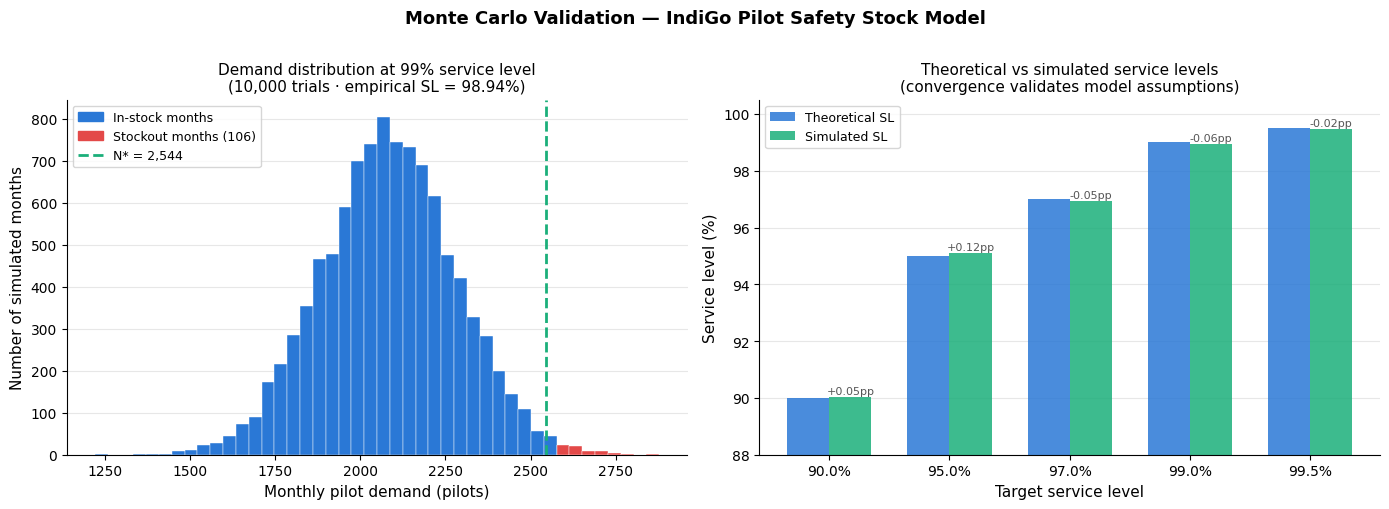

In [10]:
if __name__ == "__main__":
    main()